# TEXAS — Google Colab Quickstart

**TEXAS** (`texas-psm`) is a Bayesian proxy system model for TEX<sub>86</sub> paleothermometry.

This notebook walks through:
1. Installing CmdStan and the package
2. Downloading the pre-computed posteriors from Zenodo
3. **Forward prediction** — temperature → Scaled RI (pure Python, no Stan)
4. **Inverse reconstruction** — Scaled RI → temperature with full uncertainty (runs Stan)

---

> **Saving your work**: This notebook runs on a temporary Colab session. To keep your edits, go to **File → Save a copy in Drive** before making changes.

> **What requires Stan?**
> | Task | Stan needed? |
> |------|-------------|
> | `predict_proxy_from_T()` — plot calibration curve | ❌ No |
> | `predict_T_from_proxyObs()` — reconstruct paleotemperature | ✅ Yes |
> | `get_posterior()` — re-fit the calibration from scratch | ✅ Yes |

---

### Step 1a — Install CmdStan on Google Colab

In [1]:
# # ── Step 1a: Install CmdStan ───────────────────────────────────────────────────
# # Required before importing TEXAS. Skip this cell only if you need forward
# # prediction (predict_proxy_from_T) and NOT inverse reconstruction.
# # Takes ~5–10 minutes. Must be re-run each new Colab session.
# !pip install -q cmdstanpy
# import cmdstanpy
# cmdstanpy.install_cmdstan(version="2.36.0", progress=True)
# print(f"✅ CmdStan ready: {cmdstanpy.cmdstan_path()}")

### Step 1b — Install TEXAS

In [2]:
# # ── Step 1b: Install TEXAS ─────────────────────────────────────────────────────
# !pip install -q texas-psm

In [3]:
import os

import numpy as np
import xarray as xr
import pandas as pd

import TEXAS
print(f"TEXAS version: {TEXAS.__version__}")

TEXAS version: 0.1.10


/home/ronnie-rattan/Documents/GitHub/TEXAS/src/TEXAS/plotting/residual_maps.py:47: UserWarning: `natural_earth_v5_0_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` instead. See https://github.com/regionmask/regionmask/issues/410.
  _OCEAN_BASINS_50 = regionmask.defined_regions.natural_earth_v5_0_0.ocean_basins_50


---

## Step 2 — Mount Google Drive (optional)

Mount your Drive if your proxy data or posteriors are stored there.
Skip this cell if you plan to upload files directly or use the Zenodo download below.

In [4]:
# from google.colab import drive
# drive.mount("/content/drive")

# # Set a base path for your data on Drive — change to your folder:
# DRIVE_BASE = "/content/drive/MyDrive/texas"

# import os
# os.makedirs(DRIVE_BASE, exist_ok=True)
# print(f"Drive mounted. Working folder: {DRIVE_BASE}")

---

## Step 3 — Download the pre-computed posteriors

The forward calibration posteriors (`.nc` files) are required for both forward
and inverse predictions. Download them once from Zenodo — they are cached for
the session. If you mounted Google Drive above, point the cache there so you
don't re-download every session.



In [5]:
import os
import TEXAS

# ── Option A: cache posteriors on Google Drive (survives session restarts) ─────
# Uncomment after mounting Drive in Step 2:
# os.environ["TEXAS_CACHE_DIR"] = f"{DRIVE_BASE}/posteriors"

# ── Option B: cache in ephemeral Colab storage (re-downloaded each session) ────
# Nothing to set — default cache is used automatically.

# ── Download all posteriors from Zenodo (~560 MB ZIP, extracted ~315 MB) ───────
# TEXAS.download_all()

# ── Or download just the canonical posteriors (recommended) ────────────────────
TEXAS.download_posteriors([
    "gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3",
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3",
])

  → saved to /home/ronnie-rattan/Documents/GitHub/TEXAS/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3.nc
  → saved to /home/ronnie-rattan/Documents/GitHub/TEXAS/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3.nc


[PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3.nc'),
 PosixPath('/home/ronnie-rattan/Documents/GitHub/TEXAS/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3.nc')]

### Inspect your forward model posteriors of fitted parameters

In [10]:
from TEXAS import load_posterior


fname = f'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3'

### load_posterior() can take only file name (no *.nc file type in the string) an auto-detect whether
### the file is available from the data/cache/TEXAS_posterior_cache/ (this is a default cache dir; users can set a specific cache dir)
test_ds = load_posterior(fname)

display(test_ds)

<xarray.Dataset>
Dimensions:                (chain: 4, draw: 1000,
                            true_gdgt23ratio_crtp_dim_0: 1513,
                            true_no3_crtp_dim_0: 1513)
Coordinates:
  * chain                  (chain) int64 1 2 3 4
  * draw                   (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Dimensions without coordinates: true_gdgt23ratio_crtp_dim_0, true_no3_crtp_dim_0
Data variables:
    t0_crtp                (chain, draw) float64 34.99 37.73 ... 34.88 34.68
    k_crtp                 (chain, draw) float64 0.1546 0.2315 ... 0.1778 0.1712
    b_crtp                 (chain, draw) float64 0.4421 0.4217 ... 0.4447 0.44
    v_crtp                 (chain, draw) float64 1.976 3.64 1.928 ... 2.19 2.206
    beta_G23_crtp          (chain, draw) float64 -0.005516 ... -0.005765
    beta_NO3_crtp          (chain, draw) float64 -0.05651 -0.04214 ... -0.04409
    sigma_proxyObs_crtp    (chain, draw) float64 0.04059 0.04095 ... 0.04277
    true_gdgt23ratio_crtp  (chain, draw, true_gdgt23ratio_crtp_dim_0) float64 ...
    true_no3_crtp          (chain, draw, true_no3_crtp_dim_0) float64 0.01567...
    R2_full                (chain, draw) float64 0.8009 0.798 ... 0.8 0.8006
    bayesR2_full           (chain, draw) float64 0.8629 0.859 ... 0.8685 0.856
    RMSE_full              (chain, draw) float64 0.05103 0.05139 ... 0.05107
Attributes: (12/45)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_multiv_priorApprox...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox...
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1348.55
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS
    filename:                     gen_logi_fixed_hier_crtp_multiv_priorApprox...

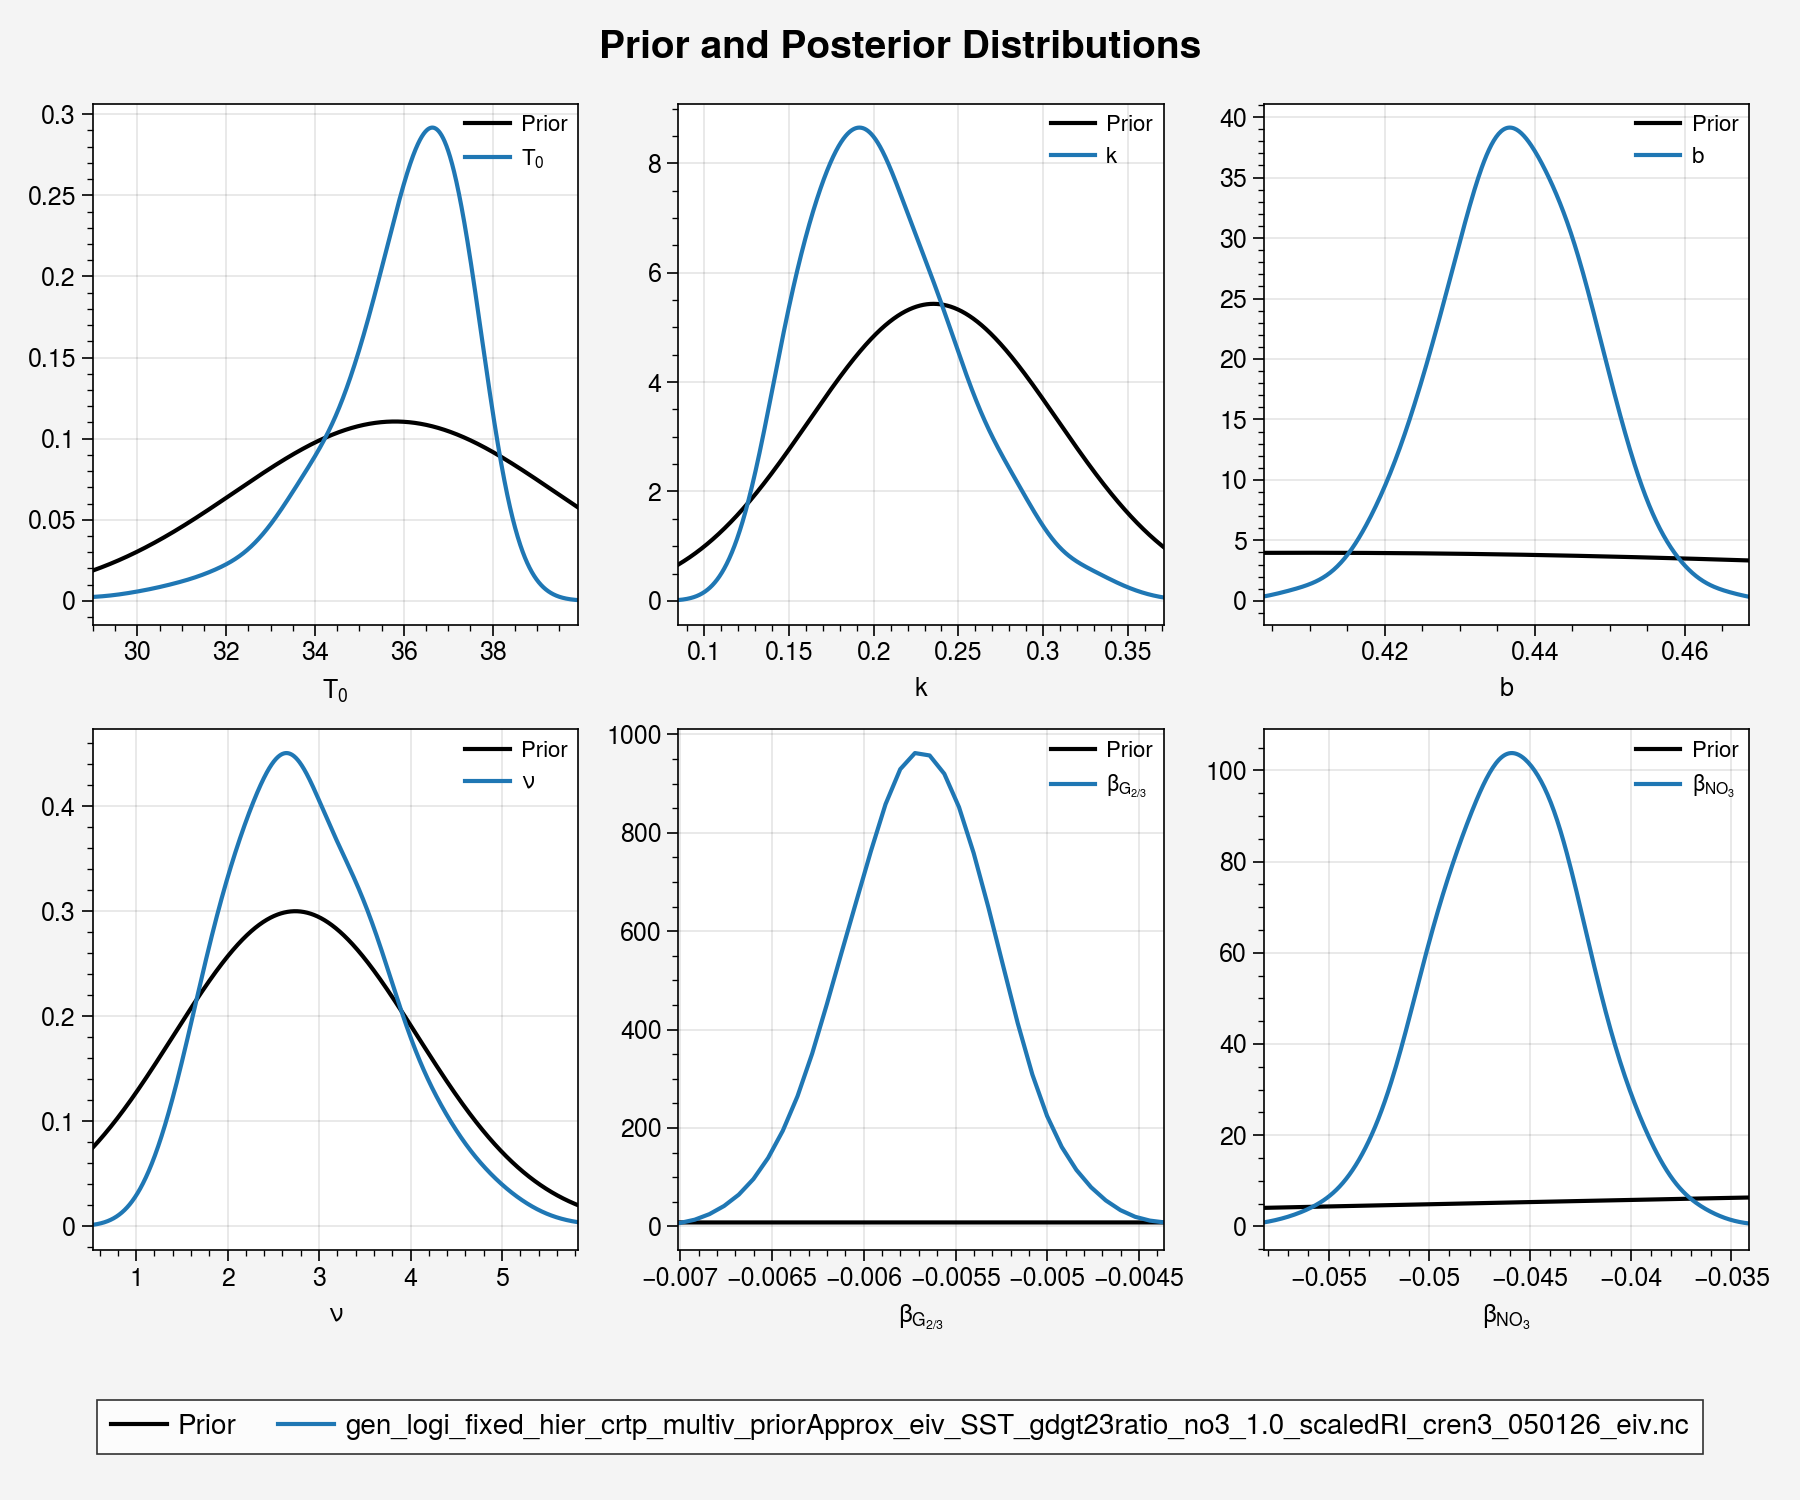

In [11]:
from TEXAS import plot_prior_distributions
fig, axs = plot_prior_distributions(
    priors_list = test_ds.attrs['priors'],
    posterior_datasets=[test_ds],
    show_histogram=False,
    show_prior_expression=False)

---

## Step 4 — Forward prediction: temperature → Scaled RI

`predict_proxy_from_T()` evaluates the calibration curve at a range of
temperatures. **No Stan required** — this is pure Python using the loaded posterior.

Use this to visualise the calibration curve or to generate forward-model
predictions from a temperature ensemble.

### Start with a toy data; simple linspace array

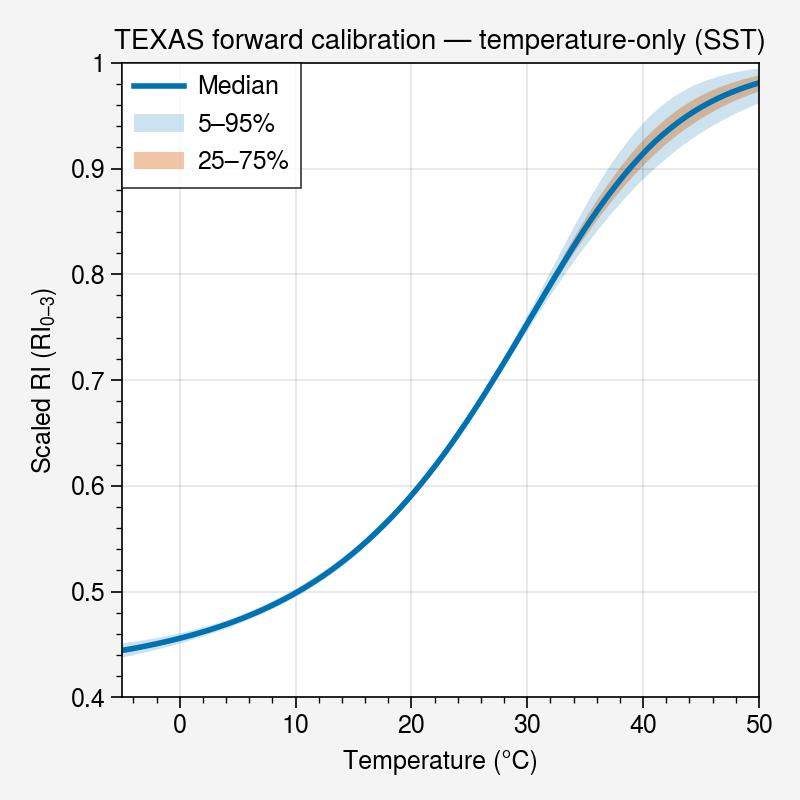

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import proplot as plot
import pandas as pd
from TEXAS import predict_proxy_from_T


### In this example, temperatures is a linspace array; an evenly-spaced array of n values between a and b in np.linspace(a,b,n)
temperatures = np.linspace(-5,60, 200)


## Temperature-only posterior (SST, canonical Scaled RI₀₋₃)
## A default value for n_draws is set at 500 --- n_draws is the number of posterior ensemble members used for forward modeling
## The function predict_proxy_from_T() uses each paired-parameters solved from the CmdStan (MCMC) to build an S-curve ensemble
## Percentiles (e.g., "p50") are calculated from the n_draws number of S-curve ensembles generate
## the pre-computed forward model posteriors used in TEXAS have 4000 members (4 chains x 1000 draws per chain)

set_n_draw = 1500 ### The code is default at 5000 if n_draws is not provided in the function signature.
result = predict_proxy_from_T(
    temperatures=temperatures,
    n_draws=set_n_draw,
    posterior="gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3",
    percentiles=[5, 25, 50, 75, 95],
)

# Plot calibration curve with uncertainty
fig, ax = plt.subplots(figsize=(4, 4))
ax.fill_between(temperatures, result["p5"],  result["p95"], alpha=0.2,  label="5–95%")
ax.fill_between(temperatures, result["p25"], result["p75"], alpha=0.35, label="25–75%")
ax.plot(temperatures, result["p50"], lw=2, label="Median")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel(u"Scaled RI (RI$_{0\u20133}$)")
ax.set_title("TEXAS forward calibration — temperature-only (SST)")
ax.set_ylim(0.4,1)
ax.set_xlim(-5,50)
ax.legend()
plt.tight_layout()
plt.show()

---

## Step 5 — Inverse reconstruction: Scaled RI → temperature

`predict_T_from_proxyObs()` reconstructs paleotemperatures from observed
Scaled RI values. **Requires CmdStan** (Step 1b).

> **Recommended pre-processing for real proxy data:**
> 1. Compute Scaled RI and GDGT-2/3 ratio from raw abundances
> 2. **Screen with Mahalanobis distance** to remove samples outside the modern coretop calibration domain
> 3. Run `predict_T_from_proxyObs()` on the screened data
>
> The PETM example in Step 5b below demonstrates this full workflow.

Replace the example data below with your own downcore or coretop Scaled RI
observations.

### Example 1: Toy data - T only

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from TEXAS import predict_T_from_proxyObs

# ── Load your data ─────────────────────────────────────────────────────────────
# Option A — from Google Drive (uncomment after Step 2):
# df = pd.read_csv(f"{DRIVE_BASE}/my_coretop_data.csv")

# Option B — upload interactively:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# Option C — example synthetic data (replace with your own):
np.random.seed(42)
n = 10
scaledRI_obs = np.random.uniform(0.35, 0.75, n)   # your downcore Scaled RI₀₋₃ values

fwd_post_name = "gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3"
# ── Run inverse reconstruction ─────────────────────────────────────────────────
result = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 15.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 10.0,    # prior uncertainty (°C) — use ~10 when uncertain
    fwd_posterior = fwd_post_name,
    temptype       = "SST",
)


07:30:52 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/.texas/stan_cache/invT_gen_logi_fixed_univ_marginal_unconstrained.stan to exe file /home/ronnie-rattan/.texas/stan_cache/invT_gen_logi_fixed_univ_marginal_unconstrained


⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
🔧 Automatically selected Stan file: invT_gen_logi_fixed_univ_marginal_unconstrained.stan
⚙️  Auto CPU config: 4 parallel chains, 7 threads/chain (reduce_sum model)
| M=500 N=10
🔧 Compiling Stan model: invT_gen_logi_fixed_univ_marginal_unconstrained.stan
   (build dir: /home/ronnie-rattan/.texas/stan_cache)


07:31:01 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/.texas/stan_cache/invT_gen_logi_fixed_univ_marginal_unconstrained
07:31:01 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_univ_marginal_unconstrained.stan
Starting Stan sampling with 10 observations...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

07:31:03 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


#### Output structure of invT model

`predict_T_from_proxyObs()` outputs a result dictionary containing following variables
- `proxyObs` --- this is the input proxy observations (e.g., Scaled RI)
- `proxy_name` --- scaledRI_cren3 is the variable name for "Scaled RI<sub>0--3<\sub>" used in texas-psm model development
- `metadata` --- a dictionary contains input data and stan diagnosis parameters
- `pxx` --- pre-computed percentiles available at p1, p5, p10, p16, p25, p50, p75, p84, p90, p95, p99

In [15]:
# ── Summary table ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    "scaledRI":  scaledRI_obs,
    "T_p5":  result["p5"],
    "T_p25": result["p25"],
    "T_p50": result["p50"],
    "T_p75": result["p75"],
    "T_p95": result["p95"],
})
results_df.round(2).head(10)

,scaledRI,T_p5,T_p25,T_p50,T_p75,T_p95
0,0.50,-1.28,6.05,10.55,14.44,18.99
1,0.73,21.22,24.88,27.15,29.34,32.42
2,0.64,12.60,18.62,21.70,24.35,27.60
3,0.59,7.95,14.46,17.98,20.70,24.32
4,0.41,-7.36,0.12,4.77,9.07,14.27
5,0.41,-7.63,0.24,5.08,9.22,14.47
6,0.37,-9.00,-1.60,2.85,7.14,12.47
7,0.70,18.27,22.67,25.20,27.38,30.72
8,0.59,7.85,14.19,17.88,20.89,24.63
9,0.63,12.08,17.99,21.11,23.81,27.29


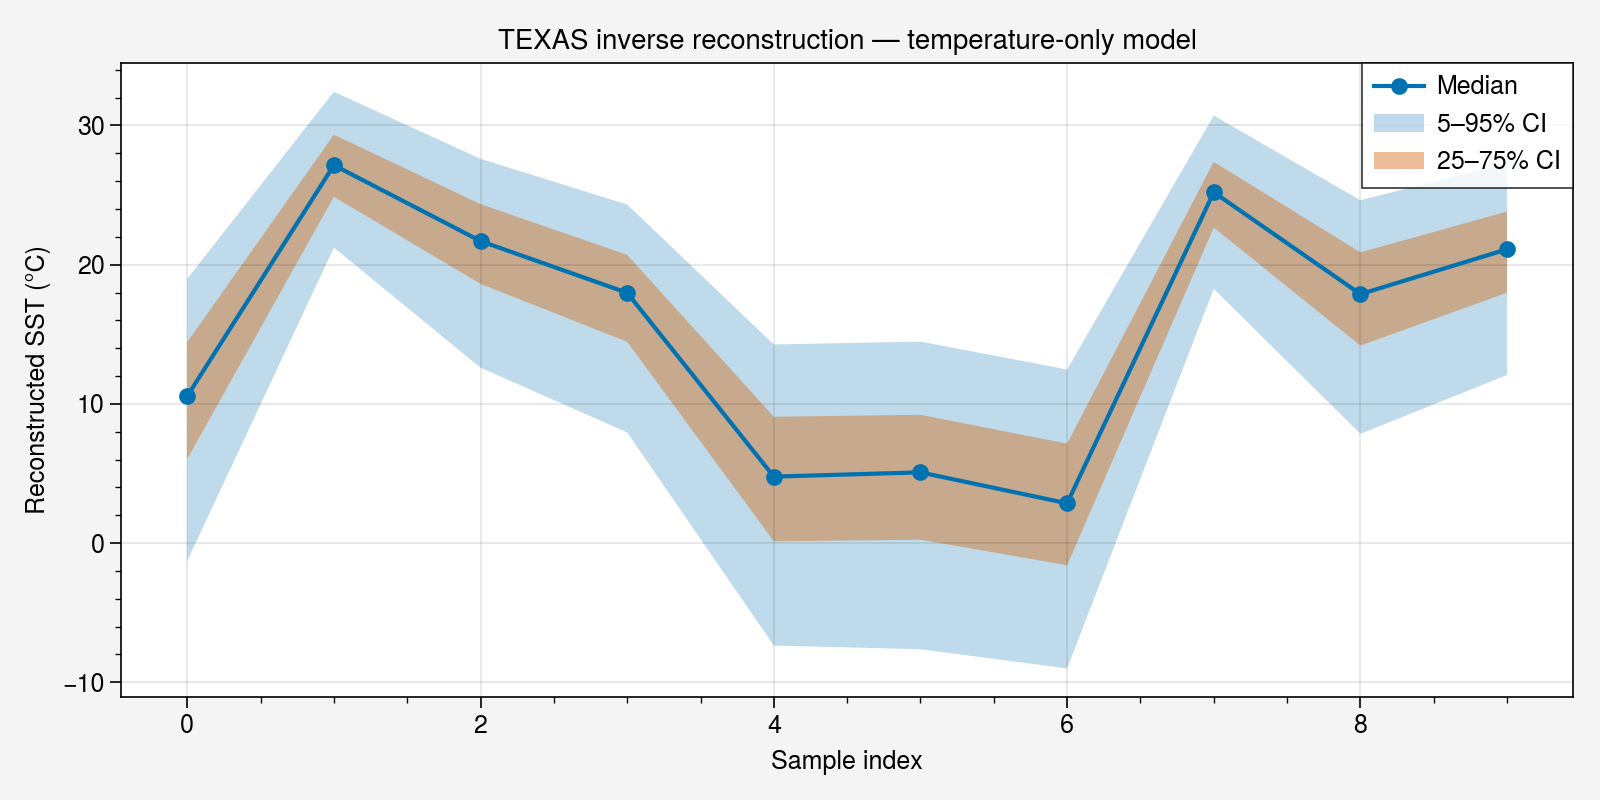

In [16]:
# ── Plot results ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
idx = np.arange(n)
ax.fill_between(idx, result["p5"], result["p95"], alpha=0.25, label="5–95% CI")
ax.fill_between(idx, result["p25"], result["p75"], alpha=0.4, label="25–75% CI")
ax.plot(idx, result["p50"], "o-", ms=5, lw=1.5, label="Median")
ax.set_xlabel("Sample index")
ax.set_ylabel("Reconstructed SST (°C)")
ax.set_title("TEXAS inverse reconstruction — temperature-only model")
ax.legend()
plt.tight_layout()
plt.show()

#### Example 1b: Toy data -- add G23 and NO3 predictors

In [17]:
np.random.seed(42)
n = 10
scaledRI_obs = np.random.uniform(0.35, 0.75, n)   # your downcore Scaled RI₀₋₃ values
gdgt23ratio_obs = np.full(scaledRI_obs.shape,15)
fwd_post_name = "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3"
# ── Run inverse reconstruction ─────────────────────────────────────────────────
result2 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 15.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 10.0,    # prior uncertainty (°C) — use ~10 when uncertain
    fwd_posterior = fwd_post_name,
    gdgt23ratio    = gdgt23ratio_obs,
    no3            = 10,
    temptype       = "SST"
)


/home/ronnie-rattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:449: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
07:31:09 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained.stan to exe file /home/ronnie-rattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained


⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
⚙️  Auto CPU config: 4 parallel chains, 7 threads/chain (reduce_sum model)
| M=500 N=10
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
   (build dir: /home/ronnie-rattan/.texas/stan_cache)


07:31:18 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained
07:31:18 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
Starting Stan sampling with 10 observations...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

07:31:21 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


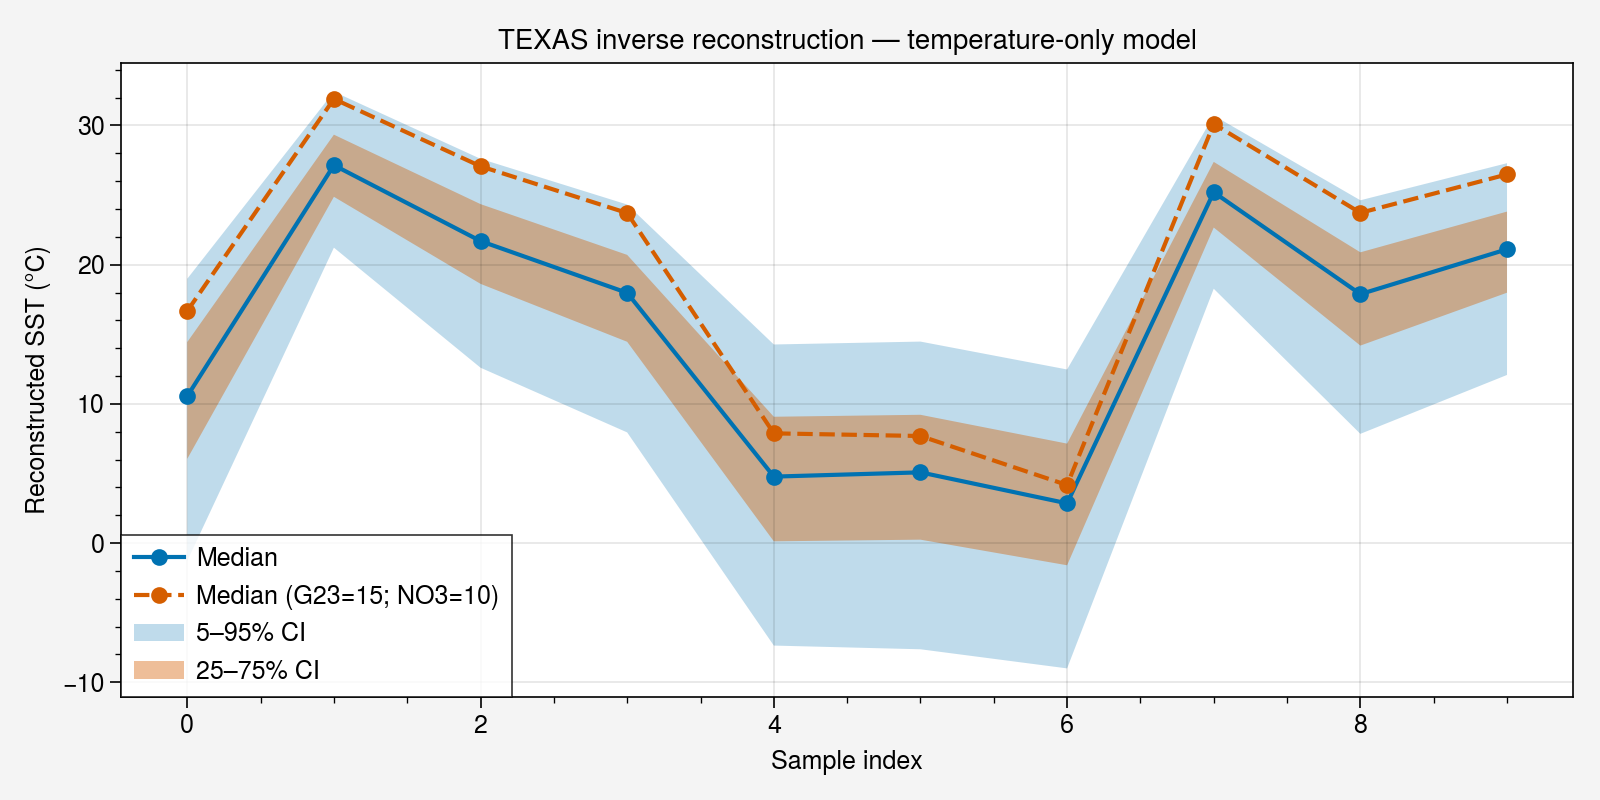

In [18]:
# ── Plot results ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
idx = np.arange(n)
ax.fill_between(idx, result["p5"], result["p95"], alpha=0.25, label="5–95% CI")
ax.fill_between(idx, result["p25"], result["p75"], alpha=0.4, label="25–75% CI")
ax.plot(idx, result["p50"], "o-", ms=5, lw=1.5, label="Median")

ax.plot(idx, result2["p50"], "o--", ms=5, lw=1.5, label="Median (G23=15; NO3=10)")


ax.set_xlabel("Sample index")
ax.set_ylabel("Reconstructed SST (°C)")
ax.set_title("TEXAS inverse reconstruction — temperature-only model")


ax.legend()
plt.tight_layout()
plt.show()

In [19]:
## Now, try to set very low nitrates
np.random.seed(42)
n = 10
scaledRI_obs = np.random.uniform(0.35, 0.75, n)   # your downcore Scaled RI₀₋₃ values
gdgt23ratio_obs = np.full(scaledRI_obs.shape, 5)
fwd_post_name = "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3"
# ── Run inverse reconstruction ─────────────────────────────────────────────────
result3 = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 15.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 10.0,    # prior uncertainty (°C) — use ~10 when uncertain
    fwd_posterior = fwd_post_name,
    gdgt23ratio    = gdgt23ratio_obs,
    no3            = 0.01,
    temptype       = "SST",
    config         = {"show_console": True}
)


/home/ronnie-rattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:449: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
07:31:21 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained.stan to exe file /home/ronnie-rattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained


⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
⚙️  Auto CPU config: 4 parallel chains, 7 threads/chain (reduce_sum model)
| M=500 N=10
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
   (build dir: /home/ronnie-rattan/.texas/stan_cache)


07:31:31 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained
07:31:31 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
Starting Stan sampling with 10 observations...
method = sample (Default)
sample
num_samples = 1000 (Default)
num_warmup = 500
save_warmup = false (Default)
thin = 1 (Default)
adapt
engaged = true (Default)
gamma = 0.05 (Default)
delta = 0.8 (Default)
kappa = 0.75 (Default)
t0 = 10 (Default)
init_buffer = 75 (Default)
term_buffer = 50 (Default)
window = 25 (Default)
save_metric = false (Default)
algorithm = hmc (Default)
hmc
engine = nuts (Default)
nuts
max_depth = 10 (Default)
metric = diag_e (Default)
metric_file =  (Default)
stepsize = 1 (Default)
stepsize_jitter = 0 (Default)
num_chains = 4
id = 1 (Default)
data
file = /tmp/tmp_n668r68/86s1gmpn.json
init = 2 (Default)
random
seed = 42
output
file = /tmp/tmp_n668r68/invT_gen_logi_fixed_multiv_marginal_unconstrainedfn4hfnyw/invT_gen_logi_fixed_multiv_marginal_unconstrained-20260505073131.csv
diagnostic_file =  (Default)
refresh = 100 (Default)
sig_figs = -1 (Default)
p

07:31:34 - cmdstanpy - INFO - CmdStan done processing


Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)

Elapsed Time: 0.901 seconds (Warm-up)
2.18 seconds (Sampling)
3.081 seconds (Total)


✅ Stan sampling completed successfully


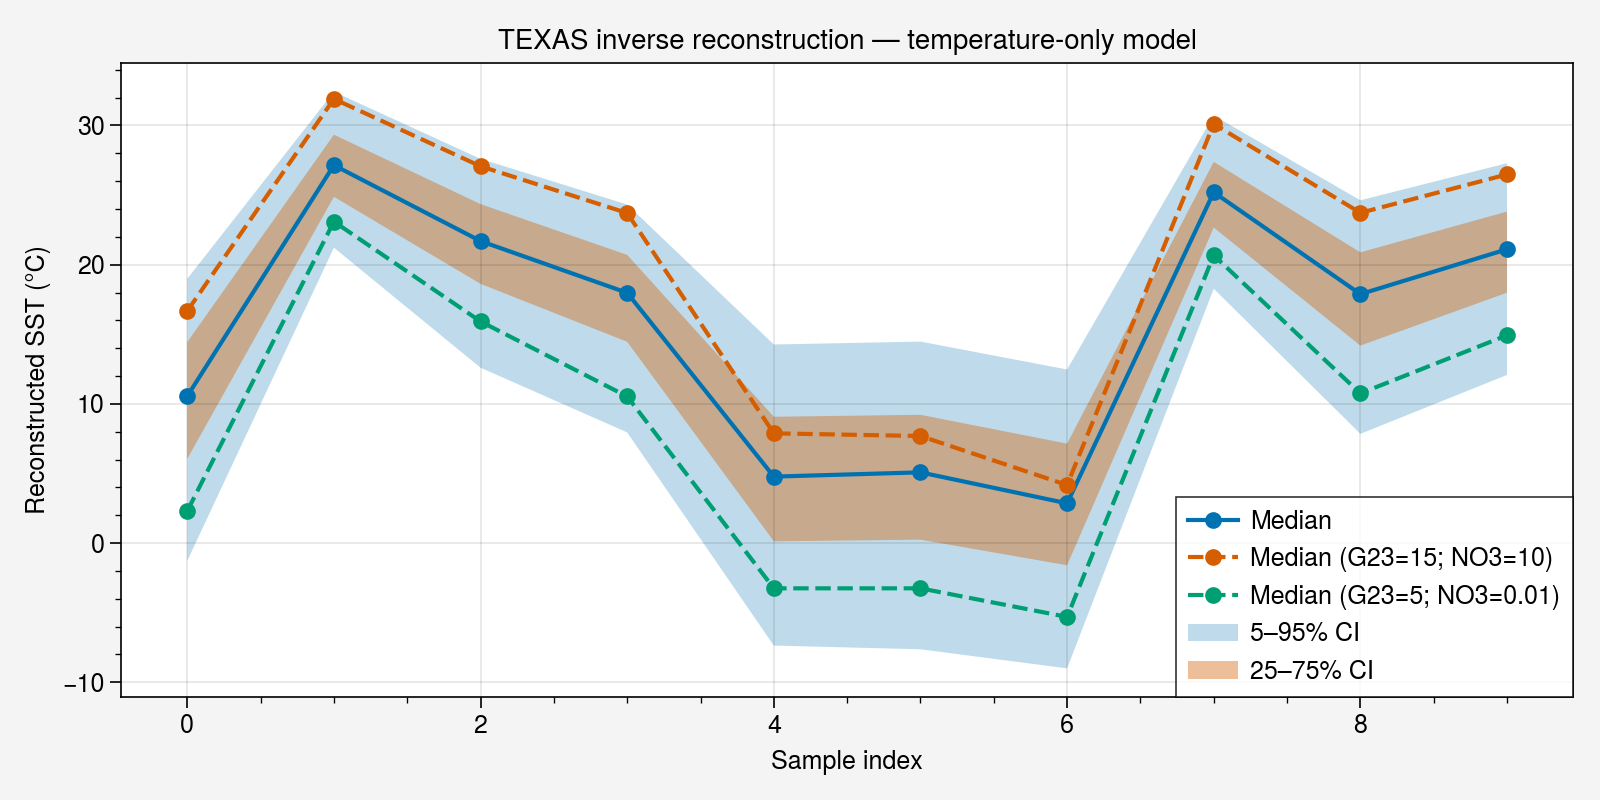

In [20]:
# ── Plot results ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
idx = np.arange(n)
ax.fill_between(idx, result["p5"], result["p95"], alpha=0.25, label="5–95% CI")
ax.fill_between(idx, result["p25"], result["p75"], alpha=0.4, label="25–75% CI")
ax.plot(idx, result["p50"], "o-", ms=5, lw=1.5, label="Median")

ax.plot(idx, result2["p50"], "o--", ms=5, lw=1.5, label="Median (G23=15; NO3=10)")
ax.plot(idx, result3["p50"], "o--", ms=5, lw=1.5, label="Median (G23=5; NO3=0.01)")

ax.set_xlabel("Sample index")
ax.set_ylabel("Reconstructed SST (°C)")
ax.set_title("TEXAS inverse reconstruction — temperature-only model")


ax.legend()
plt.tight_layout()
plt.show()

## Step 5b: Let's try with published paleo-records

In this example, we will use a PhanSST global compilation of paleoclimate proxies by [Judd et al. (2022)](https://doi.org/10.1038/s41597-022-01826-0) --- which also have TEX86!

We will read in the data using Pandas function `pd.read_csv()` which can take a url from the [NCEI Paleo Database](https://www.ncei.noaa.gov/access/paleo-search/study/36813).

In [21]:
url = 'https://www.ncei.noaa.gov/pub/data/paleo/paleocean/global/judd2022/phanSST-database.txt'

### we can read
PhanSST_df = pd.read_csv(url, sep='\t', na_values='NA', comment='#', low_memory=False, header=1)

print(PhanSST_df.shape)
print(PhanSST_df.columns.tolist())
print(PhanSST_df.head(3))

(149354, 55)
['SampleID', 'SiteName', 'SiteHole', 'MBSF', 'MCD', 'SampleDepth', 'Formation', 'Country', 'ContinentOcean', 'ModLat', 'ModLon', 'Age', 'Period', 'Stage', 'StagePosition', 'Biozone', 'AgeFlag', 'ProxyValue', 'ProxyType', 'ValueType', 'DiagenesisFlag', 'Taxon1', 'Taxon2', 'Taxon3', 'Environment', 'Ecology', 'AnalyticalTechnique', 'CL', 'Mn', 'Fe', 'Sr', 'Mg', 'Ca', 'Cawtp', 'MgCa', 'SrCa', 'MnSr', 'NBS120c', 'Durango', 'MaximumCAI', 'ModWaterDepth', 'CleaningMethod', 'GDGT0', 'GDGT1', 'GDGT2', 'GDGT3', 'Cren', 'Crenisomer', 'BIT', 'dRI', 'MI', 'LeadAuthor', 'Year', 'PublicationDOI', 'DataDOI']
  SampleID    SiteName SiteHole  MBSF  MCD  SampleDepth Formation Country  \
0      NaN  Alamedilla      NaN   NaN  NaN          NaN       NaN   Spain   
1      NaN  Alamedilla      NaN   NaN  NaN          NaN       NaN   Spain   
2      NaN  Alamedilla      NaN   NaN  NaN          NaN       NaN   Spain   

  ContinentOcean  ModLat  ...  GDGT3  Cren Crenisomer BIT dRI  MI  LeadAuthor 

We then filter only ProxyType == 'tex' to get only TEX86 data from the PhanSST database

In [22]:
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType'] == 'tex'].reset_index(drop=True)

numeric_cols = ['MBSF', 'MCD', 'SampleDepth', 'ModLat', 'ModLon', 'Age', 'ProxyValue',
                'GDGT0', 'GDGT1', 'GDGT2', 'GDGT3', 'Cren', 'Crenisomer',
                'BIT', 'dRI', 'MI', 'Year']
for col in numeric_cols:
    PhanTEX_df[col] = pd.to_numeric(PhanTEX_df[col], errors='coerce')

print(PhanTEX_df.shape)
print(PhanTEX_df['ProxyValue'].describe())

(14091, 55)
count    14091.000000
mean         0.633294
std          0.123508
min          0.261827
25%          0.558233
50%          0.643000
75%          0.704567
max          0.981431
Name: ProxyValue, dtype: float64


In [23]:
from TEXAS import compute_scaledRI
PETM_df = PhanTEX_df[PhanTEX_df['SiteName'].isin(['ODP959'])].reset_index(drop=True)
PETM_df['scaledRI_cren3'] = compute_scaledRI(PETM_df['GDGT0'], PETM_df['GDGT1'], PETM_df['GDGT2'],PETM_df['GDGT3'], PETM_df['Cren'], PETM_df['Crenisomer'])                           
PETM_df['gdgt23ratio'] = PETM_df['GDGT2']/PETM_df['GDGT3']
PETM_df = PETM_df[PETM_df['MBSF'].between(801,806)].dropna(how='any',subset=['scaledRI_cren3']).reset_index(drop=True)

### Screen proxy data with Mahalanobis distance

Before running the inverse reconstruction, flag samples that fall outside the modern coretop calibration domain using Mahalanobis distance screening.

We fit `MahalanobisOutlierDetector` on the **screened coretop training data**, restricted to samples with `gdgt23ratio ≤ 5` (low-G23 subset). Features are `TEX86` and `scaledRI_cren3` — the same pair used in model development (SI_code3). Paleo samples outside the 90% confidence ellipse are flagged as outliers; `detect_outliers_manual()` additionally retains high-RI / high-TEX86 warm end-member samples even if they lie outside the ellipse.

In [25]:
import TEXAS
import pandas as pd
from TEXAS.utils.paths import SPREADSHEETS_DIR
from TEXAS.data import MahalanobisOutlierDetector

# Download screened coretop data from Zenodo (skipped if already cached)
TEXAS.download_training_data()

# Load the gridded coretop dataset used for calibration
combined_df = pd.read_csv(
    SPREADSHEETS_DIR / 'combined_coretop_culture_mesocosm_rev20260210.csv'
)
coretop_df = combined_df[combined_df['datatype']=='coretop']
# Fit on low-G23 coretops (gdgt23ratio ≤ 5 filters ecology-dominated sites)
detector = MahalanobisOutlierDetector(['TEX86', 'scaledRI_cren3'], confidence=0.9)
detector.fit(coretop_df[coretop_df['gdgt23ratio'] <= 5])
print(f"Fitted on {int((coretop_df['gdgt23ratio'] <= 5).sum())} coretop samples (gdgt23ratio ≤ 5)")
print(f"Mahalanobis threshold (90% CI): {detector.threshold:.3f}")

All training data files already present.
Fitted on 1205 coretop samples (gdgt23ratio ≤ 5)
Mahalanobis threshold (90% CI): 2.146


In [27]:
plot_decision_boundary

NameError: name 'plot_decision_boundary' is not defined

Screened out: 0 / 40 PETM samples


/home/ronnie-rattan/Documents/GitHub/TEXAS/src/TEXAS/data/screening.py:198: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  flags.loc[valid] = (distances.loc[valid] ** 2) > (self.threshold ** 2)
/home/ronnie-rattan/Documents/GitHub/TEXAS/src/TEXAS/data/screening.py:198: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True

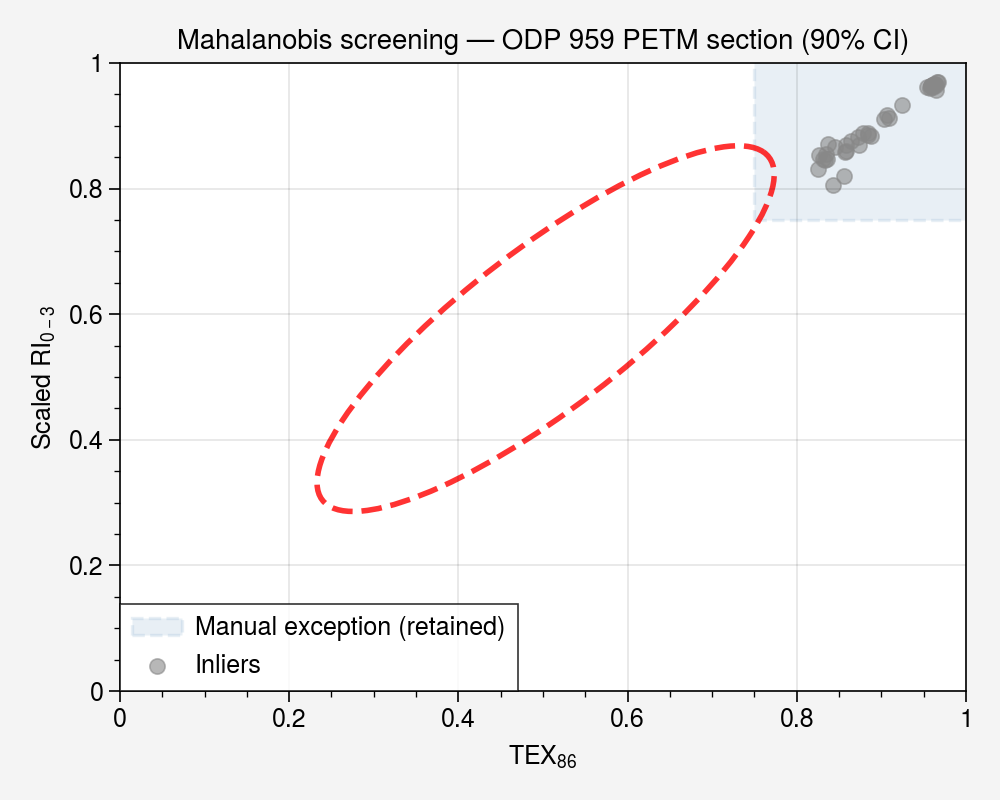

Samples passing screening: 40


In [29]:
import matplotlib.pyplot as plt                                                                                                                                
                                                                                                                                                                   
# TEX86 alias — ProxyValue column in the PhanSST database                                                                                                        
PETM_df['TEX86'] = PETM_df['ProxyValue']                                                                                                                         
                                                                                                                                                                
# Screen: flag paleo samples outside the coretop calibration domain                                                                                              
PETM_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] = detector.detect_outliers_manual(PETM_df)                                                                                                                     
                                                                                                                                                                
n_out = int(PETM_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'].sum())                                                                                 
print(f"Screened out: {n_out} / {len(PETM_df)} PETM samples")                                                                                                    
                                                                                                                                                                
# Visualise                                                                                                                                                      
fig, ax = plt.subplots(figsize=(5, 4))                                                                                                                         
detector.plot_decision_boundary(PETM_df, ax=ax)
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xlabel("TEX$_{86}$")                                                                                                                                      
ax.set_ylabel(r"Scaled RI$_{0-3}$")
ax.set_title("Mahalanobis screening — ODP 959 PETM section (90% CI)")                                                                                            
plt.tight_layout()                                                                                                                                               
plt.show()                                                                                                                                                       
                                                                                                                                                                
# Keep only inliers                                                                                                                                              
PETM_df = PETM_df[                                                                                                                                             
    PETM_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] == False
].reset_index(drop=True)                                                
print(f"Samples passing screening: {len(PETM_df)}")     

In [30]:
# Keep only inliers for temperature reconstruction
PETM_df = PETM_df[
    PETM_df['TEXRI_cren3_mahalDist_low23ratio_outliers_manual'] == False
].reset_index(drop=True)
print(f"Samples passing screening: {len(PETM_df)}")

Samples passing screening: 40


In [31]:
from TEXAS import predict_T_from_proxyObs
## Now, try to set very low nitrates
np.random.seed(42)
n = 10
scaledRI_obs = PETM_df['scaledRI_cren3']
gdgt23ratio_obs = PETM_df['gdgt23ratio']
fwd_post_name = "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3_050126_eiv"
# ── Run inverse reconstruction ─────────────────────────────────────────────────
result_PETM = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 35.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 10.0,    # prior uncertainty (°C) — use ~10 when uncertain
    fwd_posterior = fwd_post_name,
    gdgt23ratio    = gdgt23ratio_obs,
    no3            = 10,        # Put no3=10 to ignore the nutrient effect
    temptype       = "SST"
)


/home/ronnie-rattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:449: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
07:33:56 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained.stan to exe file /home/ronnie-rattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained


⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
⚙️  Auto CPU config: 4 parallel chains, 7 threads/chain (reduce_sum model)
| M=500 N=40
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
   (build dir: /home/ronnie-rattan/.texas/stan_cache)


07:34:05 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained
07:34:05 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
Starting Stan sampling with 40 observations...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

07:34:22 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


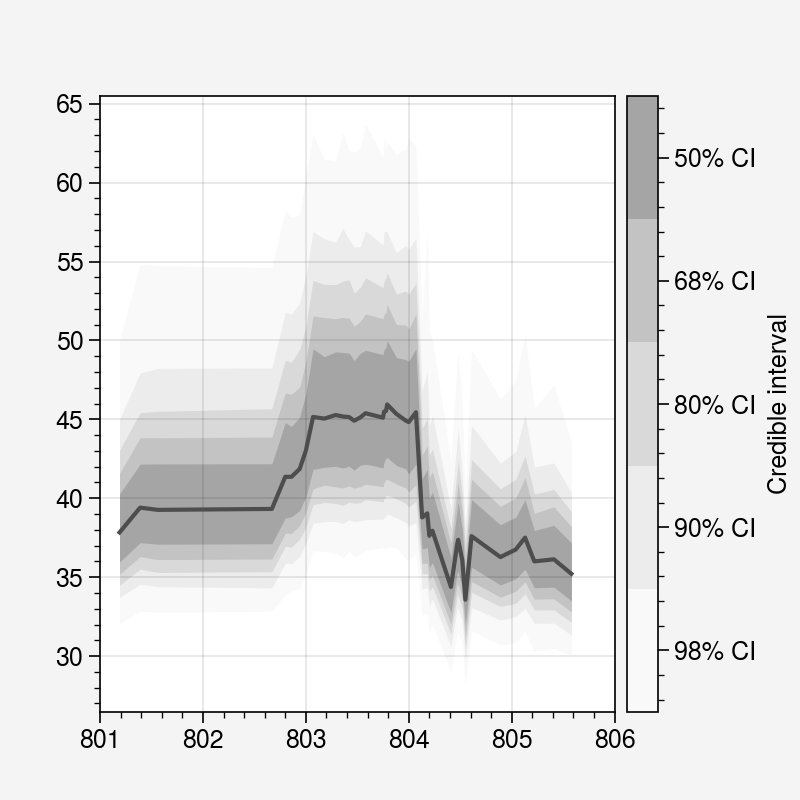

In [34]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm, ListedColormap

fig, ax = plt.subplots()
ax.plot(PETM_df['MBSF'].values, result_PETM['p50'], c='0.3', lw=1.5, zorder=5)

uncertainty_bands = [('p1','p99'), ('p5','p95'), ('p10','p90'), ('p16','p84'), ('p25','p75')]
labels = ['98% CI', '90% CI', '80% CI', '68% CI', '50% CI']

n = len(uncertainty_bands)
gray_colors = plt.get_cmap('greys')(np.linspace(0.05, 0.45, n))
for i, band in enumerate(uncertainty_bands):
    ax.fill_between(PETM_df['MBSF'].values,
                    result_PETM[band[0]], result_PETM[band[1]],
                    color=gray_colors[i], linewidth=0)

ax.set_xlim(801, 806)

# Colorbar
cmap_cb = ListedColormap(gray_colors)
bounds = np.arange(n + 1)  # [0, 1, 2, 3, 4, 5]
norm_cb = BoundaryNorm(bounds, cmap_cb.N)

sm = mpl.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, ticks=np.arange(n) + 0.5)
cbar.set_ticklabels(labels)
cbar.set_label('Credible interval')

### Comparison with existing models

`texas-psm` provides `predict_tex86_from_sst` and `predict_tex_from_tex86` for commonly-used existing models

Users can select the existing model by passying `method=xxx` with xxx options are:
- `schouten2002` --- Original linear calibration [(Schouten et al., 2002)](https://doi.org/10.1016/S0012-821X(02)00979-2)
- `kim2010_tex86H` --- $\text{TEX}_{86}^{H}$ [(Kim et al., 2010)](https://doi.org/10.1016/S0012-821X(02)00979-2)

See `TEXAS.models.CalibrationRegistry` [API link here](https://paleolipidrr.github.io/TEXAS/api/#TEXAS.models.CalibrationRegistry)

`texas-psm` installation also requires `baysparpy` and `baysplinepy` so that we can reconstruct BAYSPAR temperatures for comparison
- see `baysparpy` documentation [here](https://baysparpy.readthedocs.io/en/stable/overview.html)
- see `baysplinepy` documentation [here](https://github.com/brews/baysplinepy)

In [35]:
from TEXAS.models import predict_sst_from_tex86, predict_sst_from_tex86

PETM_df['SST_kim10_tex86h'] = predict_sst_from_tex86(PETM_df['ProxyValue'])
PETM_df['SST_schouten02'] = predict_sst_from_tex86(PETM_df['ProxyValue'],method='schouten02')

In [39]:
import bayspar as bsr

result_bsr = bsr.predict_seatemp_analog(
    tex = PETM_df['ProxyValue'],
    prior_mean = 35,
    prior_std = 10,
    temptype = 'sst',
    search_tol = 0.25
)

100%|██████████| 17/17 [00:09<00:00,  1.70it/s]


In [40]:
result_bsr.percentile(50)

/tmp/ipykernel_38955/4051869721.py:1: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  result_bsr.percentile(50)


array([38.01137732, 38.6317998 , 38.86190495, 38.32874552, 40.07277123,
       39.76525026, 39.99970086, 41.00402797, 43.06595777, 43.07709709,
       43.08402474, 42.77207479, 42.98418646, 42.90296762, 43.14635735,
       42.99436127, 43.21024319, 43.31208552, 43.49762367, 43.3873263 ,
       42.97133158, 43.1611179 , 43.3150619 , 43.35875081, 37.9914798 ,
       38.63715739, 37.14013382, 37.45315548, 36.97639268, 37.04758283,
       37.12939431, 35.84738737, 36.20888529, 35.93718614, 35.31281575,
       35.78805709, 36.38006132, 35.65323051, 35.55754512, 35.18346419])

/tmp/ipykernel_38955/327687724.py:38: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ax.plot(PETM_df['MBSF'].values,result_bsr.percentile(50),color='purple')
/tmp/ipykernel_38955/327687724.py:39: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ax.fill_between(PETM_df['MBSF'].values,result_bsr.percentile(25),result_bsr.percentile(75),color='purple',alpha=0.25)


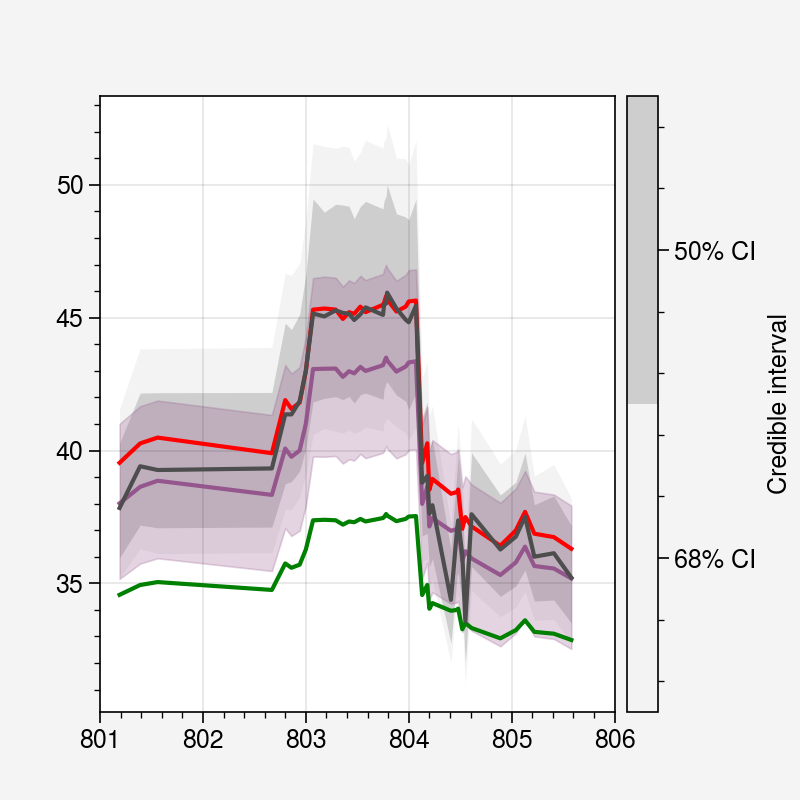

In [42]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm, ListedColormap

fig, ax = plt.subplots()
ax.plot(PETM_df['MBSF'].values, result_PETM['p50'], c='0.3', lw=1.5, zorder=5)

uncertainty_bands = [('p16','p84'), ('p25','p75')]
labels = ['68% CI', '50% CI']

n = len(uncertainty_bands)
gray_colors = plt.get_cmap('greys')(np.linspace(0.1, 0.3, n))
for i, band in enumerate(uncertainty_bands):
    ax.fill_between(PETM_df['MBSF'].values,
                    result_PETM[band[0]], result_PETM[band[1]],
                    color=gray_colors[i], linewidth=0)

ax.set_xlim(801, 806)

# Colorbar
cmap_cb = ListedColormap(gray_colors)
bounds = np.arange(n + 1)  # [0, 1, 2, 3, 4, 5]
norm_cb = BoundaryNorm(bounds, cmap_cb.N)

sm = mpl.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, ticks=np.arange(n) + 0.5)
cbar.set_ticklabels(labels)
cbar.set_label('Credible interval')

########### add additional lines from existing models
ax.plot(PETM_df['MBSF'].values,PETM_df['SST_schouten02'].values,color='red')
ax.plot(PETM_df['MBSF'].values,PETM_df['SST_kim10_tex86h'].values,color='green')

#### bayspar

ax.plot(PETM_df['MBSF'].values,result_bsr.percentile(50),color='purple')
ax.fill_between(PETM_df['MBSF'].values,result_bsr.percentile(25),result_bsr.percentile(75),color='purple',alpha=0.25)

---

## Step 6 — Save results

Save the reconstruction results back to Google Drive or download to your computer.

In [ ]:
# ── Option A: save to Google Drive ────────────────────────────────────────────
# output_path = f"{DRIVE_BASE}/texas_results.csv"
# results_df.to_csv(output_path, index=False)
# print(f"Saved to {output_path}")

# ── Option B: download to your computer ───────────────────────────────────────
results_df.to_csv("texas_results.csv", index=False)
from google.colab import files
files.download("texas_results.csv")

---

## Notes

| | Colab (free) | Colab Pro | Local / Docker |
|---|---|---|---|
| Setup time | ~10 min first session | ~10 min first session | One-time ~15 min build |
| CmdStan persistence | ❌ Re-install each session | ✅ Longer runtime | ✅ Pre-built in image |
| Posterior persistence | ✅ Cache on Google Drive | ✅ Cache on Google Drive | ✅ Local `data/` folder |
| CPUs for Stan | 2 | 2–8 | As many as your machine |
| Recommended for | Exploration, sharing | Repeated invT runs | Full analysis |

**Caching posteriors on Google Drive**: set `TEXAS_CACHE_DIR` to a Drive path before importing TEXAS (see Step 3). The ZIP (~560 MB) is downloaded once; subsequent sessions skip the download.

**Using the multivariate EIV model**: if you have GDGT-2/3 ratio and NO₃ data, use the EIV posterior for more accurate reconstructions:

```python
result = predict_T_from_proxyObs(
    proxyObs      = scaledRI_obs,
    prior_mu_t    = 15.0,
    prior_sigma_t = 10.0,
    fwd_posterior = "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3",
    gdgt23ratio   = my_g23_array,
    no3           = my_no3_array,   # or: no3=10.0 to disable NO₃ correction
    temptype      = "SST",
)
```

**Citation**: Rattanasriampaipong et al. (in prep). *TEXAS: A proxy system model for TEX₈₆ paleothermometry.* AGU Paleoceanography and Paleoclimatology.